# Compare Genuine and Synthetic Data On multiple days

## Introduction

Here we simply display the timeseries represented by the synthetic data genarated on several days.

See the notebook [evaluate-synthetic-data-quality.ipynb](./evaluate-synthetic-data-quality.ipynb) 


## Imports

In [1]:
import os
import json
import math
import pandas as pd
import numpy as np ; np.random.seed(42)
import matplotlib.pyplot as plt
from datetime import datetime

%matplotlib inline 

## Globals

In [2]:
TOP_DATA_DIR = os.path.join(os.getcwd(), "data")
os.makedirs(TOP_DATA_DIR, exist_ok = True)

# genuine 
GENUINE_DATA_DIR = "pcj-raw-data"
GENUINE_DATA_FILENAME = "Data_PCJ_Datanalytix_passages_camions_all_format_DDMMYYYY.csv"

# synthetic 
SYNTHETIC_DATA_DIR = "gemini-generated-data"
SYNTHETIC_DATA_FILENAME = "synthetic_business_data_v3_01-01-2023_31-12-2024.csv"

# Synthesis
TOP_DATA_DIR, \
    GENUINE_DATA_DIR, \
    GENUINE_DATA_FILENAME, \
    SYNTHETIC_DATA_DIR, \
    SYNTHETIC_DATA_FILENAME

('/home/kla/Workspace/ml/poc-scanning/poc-ia-predict-truck-flow-scanning-systems/notebooks/data',
 'pcj-raw-data',
 'Data_PCJ_Datanalytix_passages_camions_all_format_DDMMYYYY.csv',
 'gemini-generated-data',
 'synthetic_business_data_v3_01-01-2023_31-12-2024.csv')

## Load data

In [4]:
# genuine 
genuine_data = pd.read_csv(filepath_or_buffer=os.path.join(TOP_DATA_DIR, GENUINE_DATA_DIR, GENUINE_DATA_FILENAME), sep=",")

# convert datetime columns 
# ex. 01/05/2023 05:43:20
genuine_data["Heure Arrivée"] = pd.to_datetime(genuine_data["Heure Arrivée"], format='%d/%m/%Y %H:%M:%S')
genuine_data["Heure Départ"] = pd.to_datetime(genuine_data["Heure Départ"], format='%d/%m/%Y %H:%M:%S')

genuine_data = genuine_data.sort_values("Heure Arrivée", ascending=True)
genuine_data.head()

,Camion ID,PCJ ID,Heure Arrivée,Heure Départ,Destination,Origine,Categorie
0,289144,1,2023-05-01 05:43:20,2023-05-01 09:27:14,Burkina Faso,Togo,Camion plein
1,152658,1,2023-05-01 05:46:45,2023-05-01 08:22:17,Burkina Faso,Togo,Camion plein
2,454460,1,2023-05-01 05:50:36,2023-05-01 09:35:02,Burkina Faso,Togo,Autocar de 56 Ã 75 places
3,82730,1,2023-05-01 05:52:00,2023-05-01 09:31:55,Burkina Faso,Togo,Camion plein
4,82517,1,2023-05-01 05:52:24,2023-05-07 10:18:41,Burkina Faso,Togo,Camion plein


In [5]:
# synthetic: data are not sorted... 
synthetic_data = pd.read_csv(filepath_or_buffer=os.path.join(TOP_DATA_DIR, SYNTHETIC_DATA_DIR, SYNTHETIC_DATA_FILENAME), sep=",")

synthetic_data["Heure Arrivée"] = pd.to_datetime(synthetic_data["Heure Arrivée"], format='%d/%m/%Y %H:%M:%S')
synthetic_data["Heure Départ"] = pd.to_datetime(synthetic_data["Heure Départ"], format='%d/%m/%Y %H:%M:%S')

synthetic_data = synthetic_data.sort_values("Heure Arrivée", ascending=True)
synthetic_data.head()

,Camion ID,PCJ ID,Heure Arrivée,Heure Départ,Destination,Origine,Categorie
431,2701,1,2023-01-01 05:00:00,2023-01-01 13:51:11,Togo,Burkina Faso,Véhicule ou autocar de 09 à 14 places
674,2361,2,2023-01-01 05:02:28,2023-01-01 13:00:36,Togo,Burkina Faso,Camion plein
643,6610,3,2023-01-01 05:07:50,2023-01-01 16:42:20,Togo,Burkina Faso,Camion vide
829,3810,3,2023-01-01 05:13:13,2023-01-01 15:54:48,Togo,Burkina Faso,Camion citerne vide
381,9765,1,2023-01-01 05:14:19,2023-01-01 08:34:41,Burkina Faso,Togo,Véhicule de moins de 09 places


## Transform and plot to compare

__Genuine__

In [6]:
# merge vehicle categories  
genuine_data_t1 = genuine_data.drop(["Camion ID", "PCJ ID", "Heure Départ", "Destination", "Origine"], axis="columns", errors="ignore")
genuine_data_t1 = genuine_data_t1.astype({"Categorie": "category"})
genuine_data_t1["Categorie"] = "vehicle"
genuine_data_t1.head()

,Heure Arrivée,Categorie
0,2023-05-01 05:43:20,vehicle
1,2023-05-01 05:46:45,vehicle
2,2023-05-01 05:50:36,vehicle
3,2023-05-01 05:52:00,vehicle
4,2023-05-01 05:52:24,vehicle


In [7]:
# binning: hour
genuine_data_t2 = genuine_data_t1.sort_values("Heure Arrivée", ascending=True)
genuine_data_t2.set_index("Heure Arrivée", inplace=True)
genuine_data_t2 = genuine_data_t2.resample("1h").count().dropna().reset_index()
genuine_data_t2 = genuine_data_t2.rename(columns={"Categorie": "Nb vehicles"})
genuine_data_t2.head()

,Heure Arrivée,Nb vehicles
0,2023-05-01 05:00:00,10
1,2023-05-01 06:00:00,52
2,2023-05-01 07:00:00,90
3,2023-05-01 08:00:00,73
4,2023-05-01 09:00:00,134


__Reduce to one month of data: Genuine__

In [8]:
# define filter from d1 to d2
d1 = np.datetime64("2023-05-01") # 1st May 2023
d2 = np.datetime64("2023-05-31") # 31th May 2023
d1, d2

(numpy.datetime64('2023-05-01'), numpy.datetime64('2023-05-31'))

In [11]:
# apply filter
genuine_d1_to_d2_df = genuine_data_t2.loc[
    (genuine_data_t2["Heure Arrivée"] >= d1) \
    & (genuine_data_t2["Heure Arrivée"] <= d2)
]
genuine_d1_to_d2_df.head(30)
# print full df
# print(genuine_d1_to_d2_df.to_string()) 

,Heure Arrivée,Nb vehicles
0,2023-05-01 05:00:00,10
1,2023-05-01 06:00:00,52
2,2023-05-01 07:00:00,90
3,2023-05-01 08:00:00,73
4,2023-05-01 09:00:00,134
5,2023-05-01 10:00:00,60
6,2023-05-01 11:00:00,39
7,2023-05-01 12:00:00,45
8,2023-05-01 13:00:00,49
9,2023-05-01 14:00:00,26


<Axes: title={'center': 'Synthetic data'}, xlabel='Heure Arrivée'>

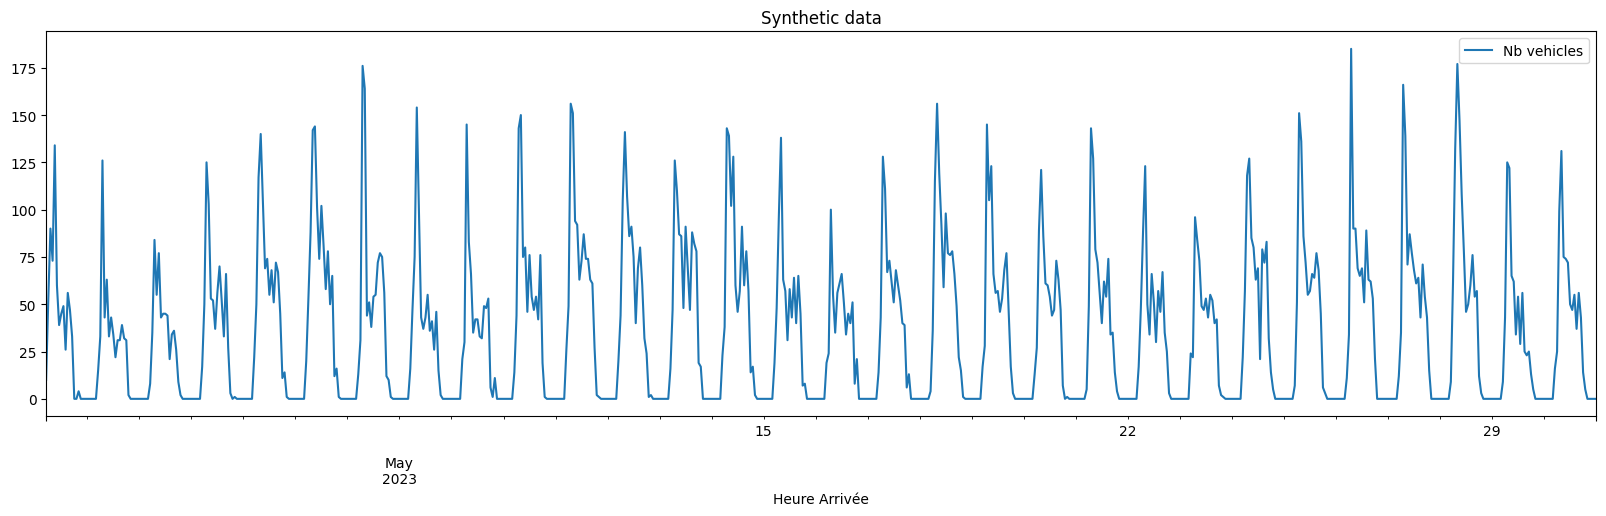

In [12]:
# plot
genuine_d1_to_d2_df_no_index = genuine_d1_to_d2_df.set_index("Heure Arrivée")
genuine_d1_to_d2_df_no_index.plot(title="Synthetic data", figsize=(20,5))

__Synthetic__

In [13]:
# merge vehicle categories  
synthetic_data_t1 = synthetic_data.drop(["Camion ID", "PCJ ID", "Heure Départ", "Destination", "Origine"], axis="columns", errors="ignore")
synthetic_data_t1 = synthetic_data_t1.astype({"Categorie": "category"})
synthetic_data_t1["Categorie"] = "vehicle"
synthetic_data_t1.head()

,Heure Arrivée,Categorie
431,2023-01-01 05:00:00,vehicle
674,2023-01-01 05:02:28,vehicle
643,2023-01-01 05:07:50,vehicle
829,2023-01-01 05:13:13,vehicle
381,2023-01-01 05:14:19,vehicle


In [14]:
# binning: hour
synthetic_data_t2 = synthetic_data_t1.sort_values("Heure Arrivée", ascending=True)
synthetic_data_t2.set_index("Heure Arrivée", inplace=True)
synthetic_data_t2 = synthetic_data_t2.resample("1h").count().dropna().reset_index()
synthetic_data_t2 = synthetic_data_t2.rename(columns={"Categorie": "Nb vehicles"})
synthetic_data_t2.head()

,Heure Arrivée,Nb vehicles
0,2023-01-01 05:00:00,28
1,2023-01-01 06:00:00,40
2,2023-01-01 07:00:00,198
3,2023-01-01 08:00:00,115
4,2023-01-01 09:00:00,129


__Plot one month of data: Syntyhetic__

In [15]:
# filter from d1 to d2
# We keep the smae d1, and d2 since they are part of our data

synthetic_d1_to_d2_df = synthetic_data_t2.loc[
    (synthetic_data_t2["Heure Arrivée"] >= d1) & \
        (synthetic_data_t2["Heure Arrivée"] <= d2)
]
synthetic_d1_to_d2_df.head(30)

,Heure Arrivée,Nb vehicles
2875,2023-05-01 00:00:00,0
2876,2023-05-01 01:00:00,0
2877,2023-05-01 02:00:00,0
2878,2023-05-01 03:00:00,0
2879,2023-05-01 04:00:00,0
2880,2023-05-01 05:00:00,40
2881,2023-05-01 06:00:00,41
2882,2023-05-01 07:00:00,197
2883,2023-05-01 08:00:00,123
2884,2023-05-01 09:00:00,126


<Axes: title={'center': 'Synthetic data'}, xlabel='Heure Arrivée'>

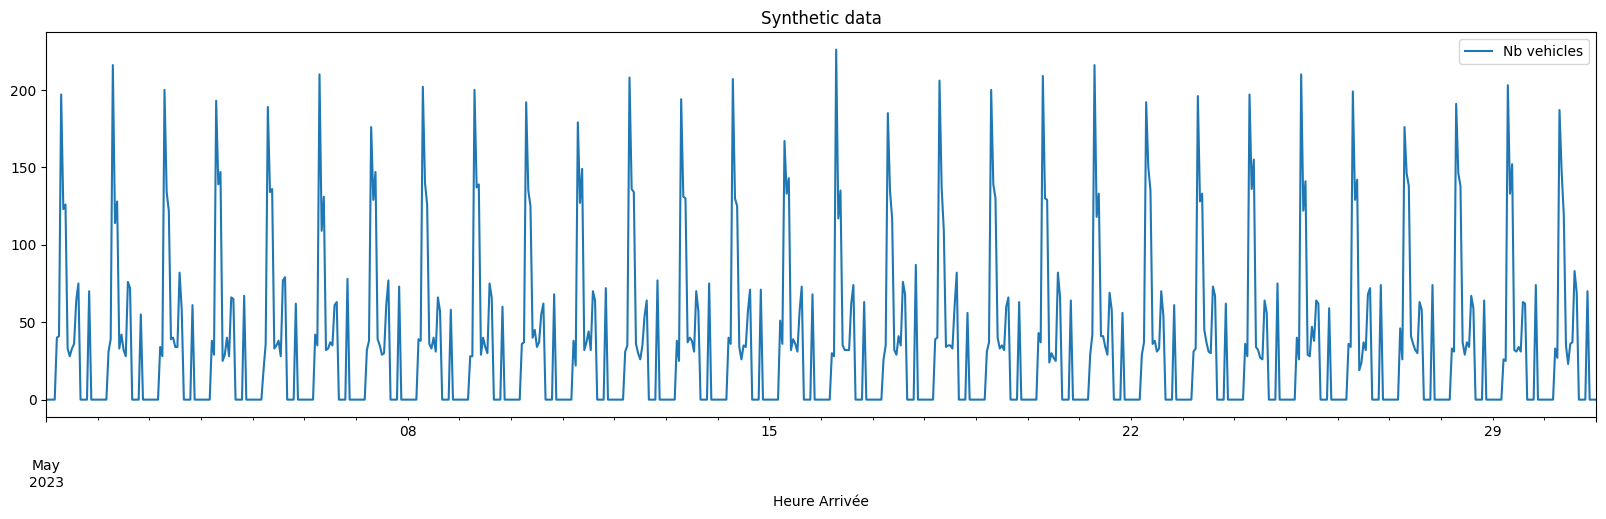

In [16]:
# plot
synthetic_d1_to_d2_df_no_index = synthetic_d1_to_d2_df.set_index("Heure Arrivée")
synthetic_d1_to_d2_df_no_index.plot(title="Synthetic data", figsize=(20,5))

__Compare other statistics on [d1, d2]__ 

In [17]:
genuine_d1_to_d2_df_no_index = genuine_d1_to_d2_df.reset_index()
genuine_d1_to_d2_df_no_index.describe()

,index,Heure Arrivée,Nb vehicles
count,716.000000,716,716.000000
mean,357.500000,2023-05-16 02:29:59.999999744,35.995810
min,0.000000,2023-05-01 05:00:00,0.000000
25%,178.750000,2023-05-08 15:45:00,0.000000
50%,357.500000,2023-05-16 02:30:00,25.000000
75%,536.250000,2023-05-23 13:15:00,60.000000
max,715.000000,2023-05-31 00:00:00,185.000000
std,206.835684,NaN,40.495584


In [18]:
synthetic_d1_to_d2_df_no_index = synthetic_d1_to_d2_df.reset_index()
synthetic_d1_to_d2_df_no_index.describe()

,index,Heure Arrivée,Nb vehicles
count,721.00000,721,721.000000
mean,3235.00000,2023-05-16 00:00:00,36.033287
min,2875.00000,2023-05-01 00:00:00,0.000000
25%,3055.00000,2023-05-08 12:00:00,0.000000
50%,3235.00000,2023-05-16 00:00:00,0.000000
75%,3415.00000,2023-05-23 12:00:00,51.000000
max,3595.00000,2023-05-31 00:00:00,226.000000
std,208.27906,NaN,51.655311


__END OF NOTEBOOK.__